# Independent recorded-source sessions: historical 2 s S8 pilot

**Historical scheduling limitation:** the 2 s / stride-64 stream cannot meet the tracker's independent confirmation-span requirement even with exact retarded bearings. Its zero confirmed tracks are not evidence about recorded-audio quality. The corrected 4.5 s protocol and results are in `s8_tracking_feasibility_validation.ipynb`; this notebook intentionally retains the original numerical outputs.

## tl;dr

- The manifest audit contains **2 calibration and 2 evaluation source sessions**, with no shared session or origin asset.
- All **8,928 dependent frame bearings** are numerically valid, but recorded-waveform errors vary sharply by session: the session-level RMSE range is **0.341–84.642°** versus **0.080–0.480°** for paired random broadband.
- **0/16 method-session tracking runs confirmed** within the deliberately limited 2 s / 9-event causal record. Therefore there are no accepted corrections and no defensible position, velocity or covariance-coverage result.
- This is a reproducible negative integration result, not evidence of tracking performance, absolute SPL, detection range or field validity.


## Context & Methods

### Key Assumptions

Four manifest-backed source recordings are treated as approximations to emitted waveforms. They already contain their original microphone, environment, background and motion. Calibration and evaluation are split by original `recording_id`, `session_id` and `origin_asset_id`, not by frames or fragments. Recorded and broadband members share trajectory, duration, timestamps and standard-normal AWGN draws.

The frozen protocol uses the existing three-station tetrahedral geometry, constant-velocity truth, 48 kHz audio, 1024/512 frame/hop, SNR −6/10 dB, tracker stride 64, unchanged `Qc=I m²/s³`, NIS thresholds and causal estimator. Recorded and broadband receive separate calibration families fitted only on the two calibration sessions.


In [1]:
from pathlib import Path
import csv
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
RESULTS = ROOT / 'results'

def read_csv(name):
    with (RESULTS / name).open(encoding='utf-8', newline='') as stream:
        return list(csv.DictReader(stream))

audit = read_csv('independent_recordings_split_audit.csv')[0]
calibration = read_csv('independent_recordings_calibration.csv')
bearings = read_csv('independent_recordings_bearing_results.csv')
sessions = read_csv('independent_recordings_session_results.csv')
summary = read_csv('independent_recordings_summary.csv')
comparisons = read_csv('independent_recordings_recorded_broadband_comparison.csv')
updates = read_csv('independent_recordings_update_results.csv')

plt.rcParams.update({'figure.figsize': (10, 4.8), 'axes.grid': True, 'grid.alpha': 0.25, 'font.size': 10})
print('scope:', audit['scope'])
print('calibration/evaluation sessions:', audit['calibration_session_count'], audit['evaluation_session_count'])
print('bearing rows / session rows / update rows:', len(bearings), len(sessions), len(updates))


scope: held_out_independent_recording_evaluation
calibration/evaluation sessions: 2 2
bearing rows / session rows / update rows: 8928 16 0


## Data

The checks below use source-session denominators. Overlapping frames and the two SNR realizations of one recording remain dependent observations and are never counted as independent source trials.


In [2]:
assert audit['source_data_independent_between_splits'] == 'True'
assert audit['declared_independence_flag_used'] == 'False'
assert audit['overlapping_session_ids'] == '[]'
assert audit['overlapping_origin_asset_ids'] == '[]'
assert len({row['paired_session_id'] for row in sessions}) == 2
assert len(bearings) == 8928
assert all(row['valid'] == 'True' for row in bearings)
assert len(updates) == 0

for row in calibration:
    assert float(row['eigenvalue_min_rad2']) > 0.0
    assert row['evaluation_used_for_calibration'] == 'False'

print('Manifest lineage audit: PASS')
print('Calibration-only positive-definite covariance audit: PASS')
print('All-frame bearing validity:', sum(row['valid'] == 'True' for row in bearings), '/', len(bearings))


Manifest lineage audit: PASS
Calibration-only positive-definite covariance audit: PASS
All-frame bearing validity: 8928 / 8928


## Results

### Bearing error by held-out source session

Bars show conditional session-level RMSE over dependent valid frames. The logarithmic scale is necessary because the mini-quadcopter on/off recording produces very large errors while the take-off/hover session at 10 dB is much closer to broadband.


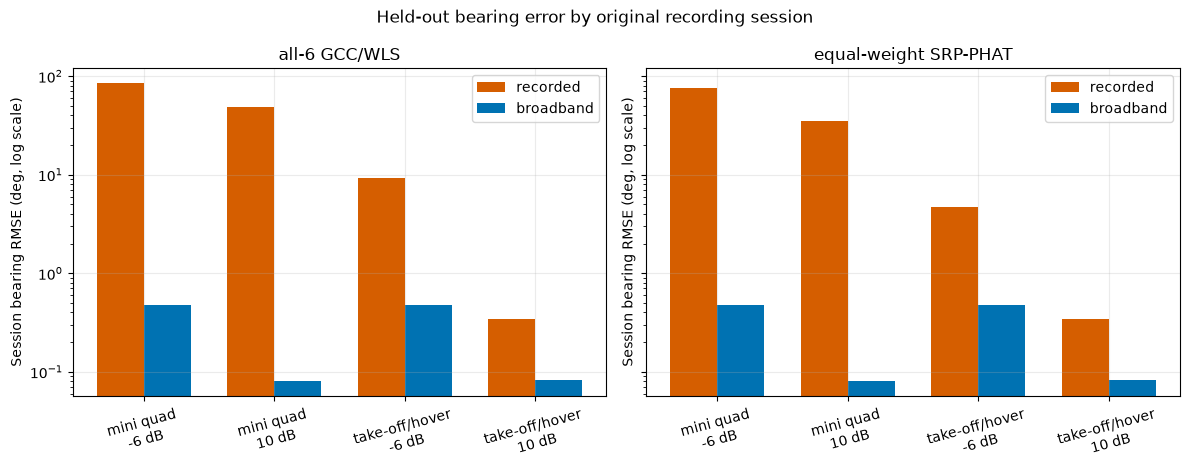

In [3]:
methods = ['all_6_equal_gcc_wls', 'equal_weight_srp_phat']
method_titles = ['all-6 GCC/WLS', 'equal-weight SRP-PHAT']
session_ids = list(dict.fromkeys(row['paired_session_id'] for row in sessions))
short_session = {session_ids[0]: 'mini quad', session_ids[1]: 'take-off/hover'}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
for ax, method, title in zip(axes, methods, method_titles):
    subset = [row for row in sessions if row['estimator_variant'] == method]
    labels = [(session, snr) for session in session_ids for snr in (-6.0, 10.0)]
    x = np.arange(len(labels))
    width = 0.36
    for offset, model, label, color in [
        (-width/2, 'recorded_source_approximation', 'recorded', '#D55E00'),
        ( width/2, 'random_broadband', 'broadband', '#0072B2'),
    ]:
        lookup = {(row['paired_session_id'], float(row['snr_db'])): float(row['bearing_rmse_deg_conditional']) for row in subset if row['source_model_comparison'] == model}
        ax.bar(x + offset, [lookup[key] for key in labels], width, label=label, color=color)
    ax.set_yscale('log')
    ax.set_xticks(x, [f"{short_session[s]}\n{snr:g} dB" for s, snr in labels], rotation=15)
    ax.set_title(title)
    ax.set_ylabel('Session bearing RMSE (deg, log scale)')
    ax.legend()
fig.suptitle('Held-out bearing error by original recording session')
fig.tight_layout()
plt.show()


### Initialization, availability and runtime

No method-session run reached a confirmed state. A zero update count is not interpreted as perfect gating: it means the filter never progressed beyond initialization. Position/velocity error and covariance coverage are consequently unavailable rather than zero.


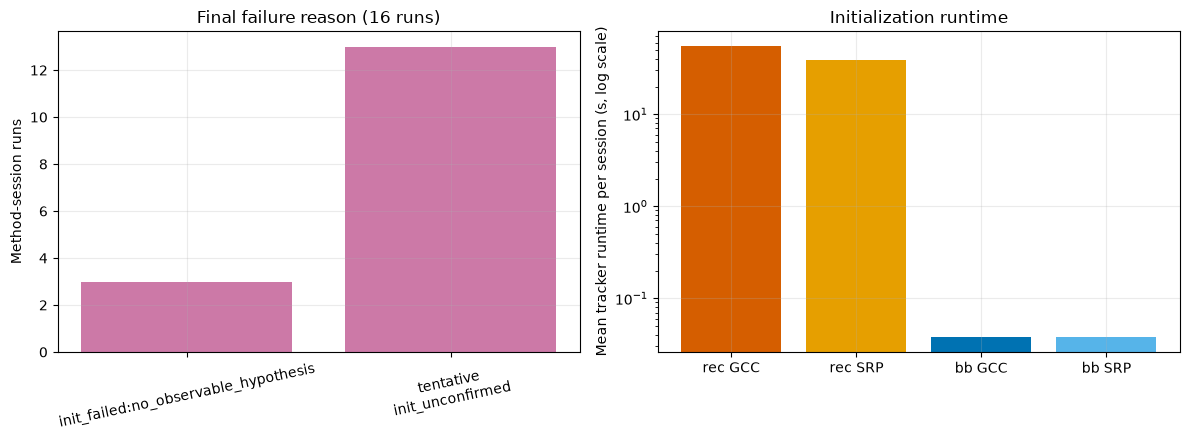

final valid: 0 / 16
confirmed: 0 / 16
accepted updates: 0
failure counts: {'initialization_failed:no_observable_hypothesis': 3, 'tentative_initialization_unconfirmed': 13}


In [4]:
failure_counts = Counter(row['failure_reason'] for row in sessions)
final_valid = sum(row['final_valid'] == 'True' for row in sessions)
confirmed = sum(row['final_confirmed'] == 'True' for row in sessions)
accepted = sum(int(row['accepted_update_count']) for row in sessions)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(range(len(failure_counts)), list(failure_counts.values()), color='#CC79A7')
axes[0].set_xticks(range(len(failure_counts)), [key.replace('initialization_', 'init_').replace('tentative_', 'tentative\n') for key in failure_counts], rotation=12)
axes[0].set_ylabel('Method-session runs')
axes[0].set_title('Final failure reason (16 runs)')

runtime_groups = {}
for row in sessions:
    key = (row['source_model_comparison'], row['estimator_variant'])
    runtime_groups.setdefault(key, []).append(float(row['tracker_runtime_s']))
labels = ['rec GCC', 'rec SRP', 'bb GCC', 'bb SRP']
ordered = [
    ('recorded_source_approximation', 'all_6_equal_gcc_wls'),
    ('recorded_source_approximation', 'equal_weight_srp_phat'),
    ('random_broadband', 'all_6_equal_gcc_wls'),
    ('random_broadband', 'equal_weight_srp_phat'),
]
axes[1].bar(labels, [np.mean(runtime_groups[key]) for key in ordered], color=['#D55E00','#E69F00','#0072B2','#56B4E9'])
axes[1].set_yscale('log')
axes[1].set_ylabel('Mean tracker runtime per session (s, log scale)')
axes[1].set_title('Initialization runtime')
fig.tight_layout()
plt.show()

print('final valid:', final_valid, '/', len(sessions))
print('confirmed:', confirmed, '/', len(sessions))
print('accepted updates:', accepted)
print('failure counts:', dict(failure_counts))


### Calibration scale

Both calibration families are positive definite, but recorded-waveform covariances are orders of magnitude larger than broadband covariances. This is descriptive evidence from two calibration sessions, not a universal source model.


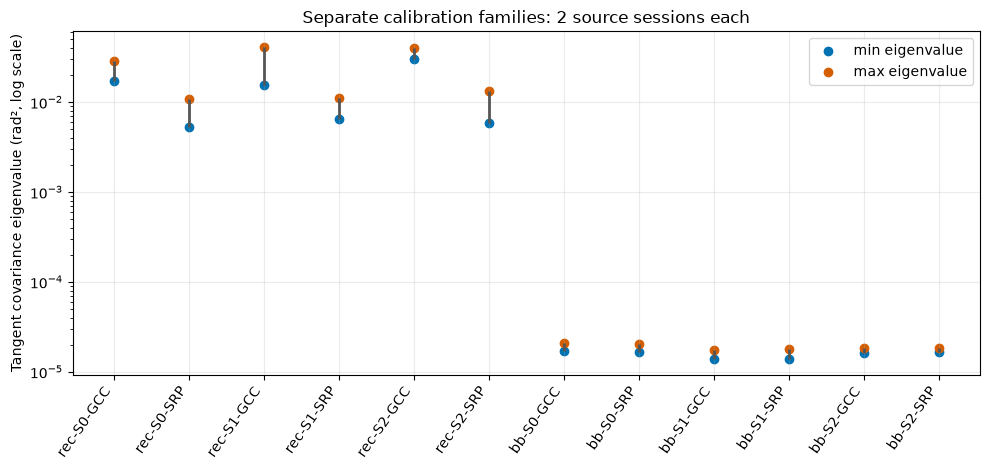

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.8))
groups = []
mins = []
maxs = []
for row in calibration:
    source = 'rec' if row['source_model_comparison'] == 'recorded_source_approximation' else 'bb'
    method = 'GCC' if row['estimator_variant'] == 'all_6_equal_gcc_wls' else 'SRP'
    groups.append(f"{source}-{row['station_id']}-{method}")
    mins.append(float(row['eigenvalue_min_rad2']))
    maxs.append(float(row['eigenvalue_max_rad2']))
x = np.arange(len(groups))
ax.vlines(x, mins, maxs, color='#555555', linewidth=2)
ax.scatter(x, mins, label='min eigenvalue', color='#0072B2')
ax.scatter(x, maxs, label='max eigenvalue', color='#D55E00')
ax.set_yscale('log')
ax.set_xticks(x, groups, rotation=55, ha='right')
ax.set_ylabel('Tangent covariance eigenvalue (rad², log scale)')
ax.set_title('Separate calibration families: 2 source sessions each')
ax.legend()
fig.tight_layout()
plt.show()


## Takeaways

1. The data-lineage requirement is satisfied at the declared manifest level: two calibration and two evaluation sessions with disjoint session/origin IDs. This does not turn four public recordings into a representative UAV population.
2. The paired broadband control remains accurate at bearing level, while recorded-source performance is strongly session-dependent. That dependence is the principal empirical S8 finding.
3. The short causal protocol did not confirm any track, including broadband controls. Consequently tracking accuracy and posterior coverage are **not validated** here; all such fields remain unavailable.
4. The mini-quadcopter recording triggered long initialization searches. Runtime is diagnostic and is not evidence of real-time readiness.
5. Remaining limitations include only two sessions per split, simulated homogeneous propagation, normalized level, unknown original environments/microphones for some sources, temporal/inter-station error correlation, hardware synchronization and field ground truth.
